In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, wilcoxon
from scipy.ndimage import laplace

In [3]:
BEFORE_COMPOSITE_PATH = "C:/Users/APURBA ROY/Desktop/SR_Revision/New folder/VGG_N.png"
AFTER_COMPOSITE_PATH  = "C:/Users/APURBA ROY/Desktop/SR_Revision/New folder/VGG_U.png"


TEST_IMAGE_PATH = "C:/Users/APURBA ROY/Desktop/SR_Revision/New folder/Resnet_U.png"

In [4]:
def split_four_panel_image(image_path):
    """
    Splits one composite image into:
    original, gradcam, lime, shap
    Assumes panels are arranged horizontally in this order:
    Original | GradCAM | LIME | SHAP
    """
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, c = img.shape
    panel_w = w // 4

    original = img[:, 0:panel_w]
    gradcam  = img[:, panel_w:2*panel_w]
    lime     = img[:, 2*panel_w:3*panel_w]
    shap     = img[:, 3*panel_w:4*panel_w]

    return original, gradcam, lime, shap

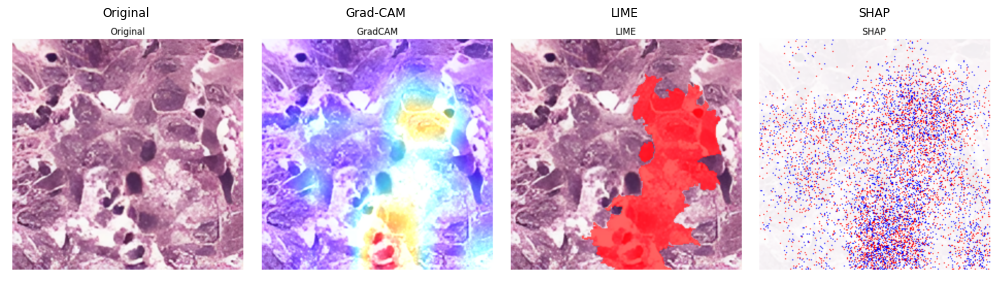

In [5]:
original, gradcam, lime, shap_img = split_four_panel_image(TEST_IMAGE_PATH)

plt.figure(figsize=(14,4))

titles = ["Original", "Grad-CAM", "LIME", "SHAP"]
imgs = [original, gradcam, lime, shap_img]

for i, (title, img) in enumerate(zip(titles, imgs)):
    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
def to_gray(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

def normalize_map(img):
    """
    Converts RGB/gray image to normalized 2D attribution map.
    """
    if img.ndim == 3:
        gray = to_gray(img)
    else:
        gray = img.copy()

    gray = gray.astype(np.float32)
    gray = gray - gray.min()

    if gray.max() > 0:
        gray = gray / gray.max()

    return gray

def laplacian_variance(img):
    """
    High-frequency content measure.
    Higher value = more sharp/high-frequency detail.
    """
    gray = to_gray(img).astype(np.float32)
    return float(laplace(gray).var())

def attribution_entropy(attr_map, eps=1e-12):
    """
    Higher entropy = more scattered/diffuse attribution.
    """
    m = normalize_map(attr_map)
    p = m.flatten()
    p = p / (p.sum() + eps)
    return float(-np.sum(p * np.log(p + eps)))

def pearson_similarity(map1, map2):
    a = normalize_map(map1).flatten()
    b = normalize_map(map2).flatten()

    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan

    return float(pearsonr(a, b)[0])

def spearman_similarity(map1, map2):
    a = normalize_map(map1).flatten()
    b = normalize_map(map2).flatten()

    if np.std(a) == 0 or np.std(b) == 0:
        return np.nan

    return float(spearmanr(a, b)[0])

def top_percent_mask(attr_map, percent=10):
    m = normalize_map(attr_map)
    threshold = np.percentile(m, 100 - percent)
    return m >= threshold

def top10_jaccard(map1, map2):
    a = top_percent_mask(map1, percent=10)
    b = top_percent_mask(map2, percent=10)

    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()

    if union == 0:
        return np.nan

    return float(inter / union)

def gaussian_smooth_panel(img, ksize=5, sigma=1.2):
    return cv2.GaussianBlur(img, (ksize, ksize), sigma)

In [7]:
original, gradcam, lime, shap_img = split_four_panel_image(TEST_IMAGE_PATH)

shap_smooth = gaussian_smooth_panel(shap_img)

result = {
    "original_high_frequency_laplacian_variance": laplacian_variance(original),
    "shap_entropy": attribution_entropy(shap_img),
    "shap_entropy_after_smoothing": attribution_entropy(shap_smooth),
    "shap_vs_smoothed_pearson": pearson_similarity(shap_img, shap_smooth),
    "shap_vs_smoothed_spearman": spearman_similarity(shap_img, shap_smooth),
    "shap_vs_smoothed_top10_jaccard": top10_jaccard(shap_img, shap_smooth),
}

pd.DataFrame([result])

,original_high_frequency_laplacian_variance,shap_entropy,shap_entropy_after_smoothing,shap_vs_smoothed_pearson,shap_vs_smoothed_spearman,shap_vs_smoothed_top10_jaccard
0,621.575317,12.231753,12.245345,0.852588,0.851812,0.855654


In [8]:
def compare_before_after_composites(before_path, after_path):
    before_original, before_gradcam, before_lime, before_shap = split_four_panel_image(before_path)
    after_original, after_gradcam, after_lime, after_shap = split_four_panel_image(after_path)

    after_shap_smooth = gaussian_smooth_panel(after_shap)

    row = {
        "before_file": os.path.basename(before_path),
        "after_file": os.path.basename(after_path),

        # High-frequency content from original panel
        "hf_original_before": laplacian_variance(before_original),
        "hf_original_after_sr": laplacian_variance(after_original),
        "hf_original_after_sr_smoothed": laplacian_variance(gaussian_smooth_panel(after_original)),

        # SHAP entropy
        "shap_entropy_before": attribution_entropy(before_shap),
        "shap_entropy_after_sr": attribution_entropy(after_shap),
        "shap_entropy_after_sr_smoothed": attribution_entropy(after_shap_smooth),

        # SHAP similarity
        "shap_pearson_before_vs_after_sr": pearson_similarity(before_shap, after_shap),
        "shap_pearson_before_vs_after_sr_smoothed": pearson_similarity(before_shap, after_shap_smooth),

        "shap_spearman_before_vs_after_sr": spearman_similarity(before_shap, after_shap),
        "shap_spearman_before_vs_after_sr_smoothed": spearman_similarity(before_shap, after_shap_smooth),

        "shap_top10_jaccard_before_vs_after_sr": top10_jaccard(before_shap, after_shap),
        "shap_top10_jaccard_before_vs_after_sr_smoothed": top10_jaccard(before_shap, after_shap_smooth),
    }

    return row

In [9]:
row = compare_before_after_composites(BEFORE_COMPOSITE_PATH, AFTER_COMPOSITE_PATH)
pd.DataFrame([row])

,before_file,after_file,hf_original_before,hf_original_after_sr,hf_original_after_sr_smoothed,shap_entropy_before,shap_entropy_after_sr,shap_entropy_after_sr_smoothed,shap_pearson_before_vs_after_sr,shap_pearson_before_vs_after_sr_smoothed,shap_spearman_before_vs_after_sr,shap_spearman_before_vs_after_sr_smoothed,shap_top10_jaccard_before_vs_after_sr,shap_top10_jaccard_before_vs_after_sr_smoothed
0,VGG_N.png,VGG_U.png,579.506775,621.575317,53.310822,12.231689,12.231359,12.244026,0.122678,0.160206,0.548748,0.443787,0.99984,0.853186


In [14]:
BEFORE_FOLDER = "C:/Users/APURBA ROY/Desktop/SR_Revision/JUNE_Revision/code/Before"
AFTER_FOLDER  = "C:/Users/APURBA ROY/Desktop/SR_Revision/JUNE_Revision/code/After"

OUTPUT_CSV = "shap_stability_from_composite_images.csv"

def get_image_files(folder):
    exts = [".png", ".jpg", ".jpeg", ".tif", ".tiff"]
    return sorted([
        f for f in os.listdir(folder)
        if os.path.splitext(f.lower())[1] in exts
    ])

before_files = get_image_files(BEFORE_FOLDER)
after_files = get_image_files(AFTER_FOLDER)


common_files = sorted(list(set(before_files).intersection(set(after_files))))

print("Matched composite pairs:", len(common_files))

results = []

for fname in common_files:
    before_path = os.path.join(BEFORE_FOLDER, fname)
    after_path = os.path.join(AFTER_FOLDER, fname)

    try:
        row = compare_before_after_composites(before_path, after_path)
        row["image_name"] = fname
        results.append(row)
    except Exception as e:
        print("Error:", fname, e)

results_df = pd.DataFrame(results)
results_df.to_csv(OUTPUT_CSV, index=False)

print("Saved:", OUTPUT_CSV)
results_df.head()

Matched composite pairs: 3
Saved: shap_stability_from_composite_images.csv


,before_file,after_file,hf_original_before,hf_original_after_sr,hf_original_after_sr_smoothed,shap_entropy_before,shap_entropy_after_sr,shap_entropy_after_sr_smoothed,shap_pearson_before_vs_after_sr,shap_pearson_before_vs_after_sr_smoothed,shap_spearman_before_vs_after_sr,shap_spearman_before_vs_after_sr_smoothed,shap_top10_jaccard_before_vs_after_sr,shap_top10_jaccard_before_vs_after_sr_smoothed,image_name
0,Inception_U.png,Inception_U.png,526.426331,649.606323,63.080883,12.244657,12.244861,12.252166,0.105349,0.186727,0.624430,0.483138,0.998479,0.853106,Inception_U.png
1,Resnet_U.png,Resnet_U.png,579.506775,621.575317,53.310822,12.231377,12.231753,12.245345,0.156389,0.225115,0.557193,0.497147,0.999719,0.855414,Resnet_U.png
2,VGG_U.png,VGG_U.png,579.506775,621.575317,53.310822,12.231689,12.231359,12.244026,0.122678,0.160206,0.548748,0.443787,0.999840,0.853186,VGG_U.png


In [15]:
summary = pd.DataFrame({
    "Metric": [
        "High-frequency energy before SR",
        "High-frequency energy after SR",
        "High-frequency energy after SR smoothing",
        "SHAP entropy before SR",
        "SHAP entropy after SR",
        "SHAP entropy after SR smoothing",
        "SHAP Pearson similarity: before vs after SR",
        "SHAP Pearson similarity: before vs after SR smoothing",
        "SHAP top-10% Jaccard: before vs after SR",
        "SHAP top-10% Jaccard: before vs after SR smoothing",
    ],
    "Mean ± SD": [
        f"{results_df['hf_original_before'].mean():.3f} ± {results_df['hf_original_before'].std():.3f}",
        f"{results_df['hf_original_after_sr'].mean():.3f} ± {results_df['hf_original_after_sr'].std():.3f}",
        f"{results_df['hf_original_after_sr_smoothed'].mean():.3f} ± {results_df['hf_original_after_sr_smoothed'].std():.3f}",
        f"{results_df['shap_entropy_before'].mean():.3f} ± {results_df['shap_entropy_before'].std():.3f}",
        f"{results_df['shap_entropy_after_sr'].mean():.3f} ± {results_df['shap_entropy_after_sr'].std():.3f}",
        f"{results_df['shap_entropy_after_sr_smoothed'].mean():.3f} ± {results_df['shap_entropy_after_sr_smoothed'].std():.3f}",
        f"{results_df['shap_pearson_before_vs_after_sr'].mean():.3f} ± {results_df['shap_pearson_before_vs_after_sr'].std():.3f}",
        f"{results_df['shap_pearson_before_vs_after_sr_smoothed'].mean():.3f} ± {results_df['shap_pearson_before_vs_after_sr_smoothed'].std():.3f}",
        f"{results_df['shap_top10_jaccard_before_vs_after_sr'].mean():.3f} ± {results_df['shap_top10_jaccard_before_vs_after_sr'].std():.3f}",
        f"{results_df['shap_top10_jaccard_before_vs_after_sr_smoothed'].mean():.3f} ± {results_df['shap_top10_jaccard_before_vs_after_sr_smoothed'].std():.3f}",
    ]
})

summary

,Metric,Mean ± SD
0,High-frequency energy before SR,561.813 ± 30.646
1,High-frequency energy after SR,630.919 ± 16.184
2,High-frequency energy after SR smoothing,56.568 ± 5.641
3,SHAP entropy before SR,12.236 ± 0.008
4,SHAP entropy after SR,12.236 ± 0.008
5,SHAP entropy after SR smoothing,12.247 ± 0.004
6,SHAP Pearson similarity: before vs after SR,0.128 ± 0.026
7,SHAP Pearson similarity: before vs after SR sm...,0.191 ± 0.033
8,SHAP top-10% Jaccard: before vs after SR,0.999 ± 0.001
9,SHAP top-10% Jaccard: before vs after SR smoot...,0.854 ± 0.001


In [16]:
def run_wilcoxon(col1, col2, label):
    a = results_df[col1].astype(float).values
    b = results_df[col2].astype(float).values

    mask = ~np.isnan(a) & ~np.isnan(b)
    a = a[mask]
    b = b[mask]

    if len(a) < 3:
        print(label, ": not enough valid samples")
        return

    stat, p = wilcoxon(a, b)
    print(f"{label}: W = {stat:.3f}, p = {p:.6f}")

run_wilcoxon(
    "hf_original_before",
    "hf_original_after_sr",
    "High-frequency energy: before vs after SR"
)

run_wilcoxon(
    "hf_original_after_sr",
    "hf_original_after_sr_smoothed",
    "High-frequency energy: after SR vs after SR smoothing"
)

run_wilcoxon(
    "shap_entropy_after_sr",
    "shap_entropy_after_sr_smoothed",
    "SHAP entropy: after SR vs after SR smoothing"
)

run_wilcoxon(
    "shap_pearson_before_vs_after_sr",
    "shap_pearson_before_vs_after_sr_smoothed",
    "SHAP Pearson similarity: before-vs-SR compared with before-vs-SR-smoothed"
)

High-frequency energy: before vs after SR: W = 0.000, p = 0.250000
High-frequency energy: after SR vs after SR smoothing: W = 0.000, p = 0.250000
SHAP entropy: after SR vs after SR smoothing: W = 0.000, p = 0.250000
SHAP Pearson similarity: before-vs-SR compared with before-vs-SR-smoothed: W = 0.000, p = 0.250000


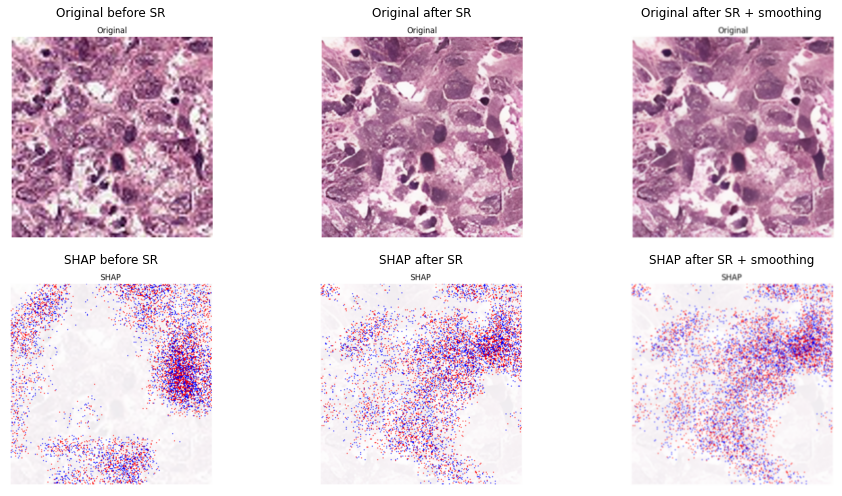

In [18]:
def show_pair_analysis(before_path, after_path):
    before_original, before_gradcam, before_lime, before_shap = split_four_panel_image(before_path)
    after_original, after_gradcam, after_lime, after_shap = split_four_panel_image(after_path)
    after_shap_smooth = gaussian_smooth_panel(after_shap)

    plt.figure(figsize=(14, 7))

    panels = [
        before_original, after_original, gaussian_smooth_panel(after_original),
        before_shap, after_shap, after_shap_smooth
    ]

    titles = [
        "Original before SR",
        "Original after SR",
        "Original after SR + smoothing",
        "SHAP before SR",
        "SHAP after SR",
        "SHAP after SR + smoothing"
    ]

    for i, (img, title) in enumerate(zip(panels, titles)):
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.savefig("example_shap_stability_from_composite.png", dpi=300)
    plt.show()


show_pair_analysis(BEFORE_COMPOSITE_PATH, AFTER_COMPOSITE_PATH)